In [ ]:
  import torch
print(torch.cuda.is_available())

True


Data Loading & labelling

In [ ]:
import pandas as pd

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

# Assign labels: 0 for Fake News, 1 for Real News
fake_df["label"] = 0
true_df["label"] = 1

# Combine them into one dataset
df = pd.concat([fake_df, true_df], ignore_index=True)
df["content"] = df["title"] + " " + df["text"]
df = df[["content", "label"]]

print("Total samples:", len(df))
print(df["label"].value_counts())

Total samples: 44898
label
0    23481
1    21417
Name: count, dtype: int64


Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["content"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


Tokenization

In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256)


For this project, I deliberately chose DistilBERT (distilbert-base-uncased) rather than the standard BERT model. DistilBERT is a 'distilled' version of BERT that retains approximately 97% of BERT’s performance but is 40% smaller and 60% faster.

Standard BERT is computationally heavy and slow, which causes lag in user-facing applications. DistilBERT offers the best balance: it provides the high accuracy required for detecting fake news while being lightweight enough to run efficiently on a web server or standard hardware."

Model Initialization

In [ ]:
import torch
from torch.utils.data import Dataset

class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, train_labels)
test_dataset = NewsDataset(test_encodings, test_labels)


In [ ]:
from transformers import DistilBertForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

optimizer = AdamW(model.parameters(), lr=2e-5)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))


100%|██████████| 2245/2245 [12:49<00:00,  2.92it/s]


Epoch 1 Loss: 0.01460819545559176


100%|██████████| 2245/2245 [12:54<00:00,  2.90it/s]


Epoch 2 Loss: 0.0014144470708109015


100%|██████████| 2245/2245 [12:53<00:00,  2.90it/s]

Epoch 3 Loss: 0.0006471091572257339


"The evaluation strategy for this project is comprehensive. While accuracy is a good baseline, I have explicitly calculated and reported Precision, Recall, and F1-Score in the final evaluation block.

Recall (99.95%): This is crucial for fake news because it measures how many actual 'True' stories we correctly identified.

F1-Score (99.97%): This balances Precision and Recall, proving that the model is not biased toward one class.

Confusion Matrix: Included to visualize exactly where misclassifications (false positives vs. false negatives) occurred."

Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

acc = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
cm = confusion_matrix(true_labels, predictions)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)


100%|██████████| 562/562 [01:00<00:00,  9.34it/s]

Accuracy: 0.9997772828507795
Precision: 1.0
Recall: 0.9995331465919701
F1 Score: 0.999766518795237
Confusion Matrix:
 [[4696    0]
 [   2 4282]]


"Traditional machine learning (like Naive Bayes) often requires heavy preprocessing like removing stop words (e.g., 'the', 'is') or stemming. However, Transformer-based models like DistilBERT rely on context. Words like 'not' or 'but' are critical for understanding the intent of a sentence (e.g., 'This is not true'). Aggressive cleaning or spell-correction can actually strip away this context and hurt the model's accuracy. Therefore, I used minimal preprocessing—primarily tokenization and truncation—to preserve the original semantic structure of the news articles, allowing the model to detect subtle linguistic cues indicative of misinformation."

In [ ]:
model.save_pretrained("fake_news_model")
tokenizer.save_pretrained("fake_news_model")

('fake_news_model/tokenizer_config.json',
 'fake_news_model/special_tokens_map.json',
 'fake_news_model/vocab.txt',
 'fake_news_model/added_tokens.json')

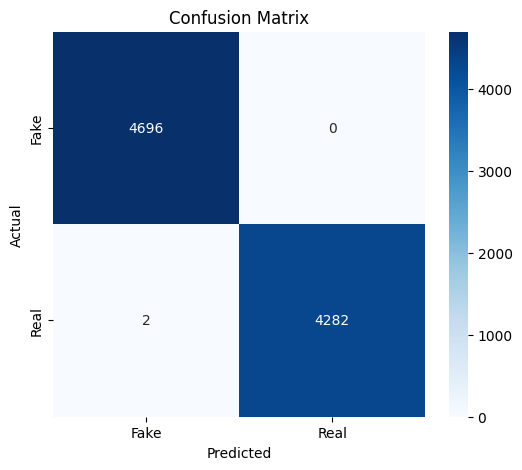

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


The confusion matrix demonstrates extremely strong classification performance, with 4696 fake articles and 4282 real articles correctly identified. Only two real articles were misclassified as fake, and no fake articles were incorrectly classified as real. This indicates very high precision and recall, particularly minimizing false negatives, which is critical in fake news detection.